In [1]:
import numpy as np
from numpy.linalg import solve, norm 
import matplotlib.pyplot as plt

Copy essential parts from `template4.ipynb`

In [2]:
def newton(f,Df,x0,n_iter=200,tol=1e-8):
    x = x0.copy()
    for i in range(n_iter):
        fsol = f(x)
        if fsol.dot(fsol) < tol**2:
            break
        delta = solve(Df(x),fsol)
        x -= delta
    assert i < n_iter-1, "Newton did not converge"
    return x

# Forward Euler stepper
def forwardEuler(f,tau,t0,y0):
    return y0 + tau*f(t0,y0)
# Backward Euler stepper
def backwardEuler(f,Df,tau,t0,y0):
    F = lambda x: x - y0 - tau*f(t0+tau,x)
    DF = lambda x: np.eye(len(y0)) - tau*Df(t0+tau,x)
    return newton(F,DF,y0,100,1e-8)
# Trapezoidal stepper
def trapezoidal(f,Df,tau,t0,y0):
    y = y0 + tau/2*f(t0,y0)
    F = lambda x: x - y - tau/2*f(t0+tau,x)
    DF = lambda x: np.eye(len(y0)) - tau/2*Df(t0+tau,x)
    return newton(F,DF,y0,100,1e-8)

In [3]:
def evolve(stepper,tau,N,y0):
    t = np.zeros( N+1 )
    y = np.zeros( (len(y0), N+1) )
    t[0] = 0
    y[:,0] = y0
    for n in range(N):
        t[n+1] = t[n] + tau
        y[:,n+1] = stepper(tau,t[n],y[:,n])
    return t,y

## Problem definitions

In [4]:
class VectorProblem:
    def __init__(self):
        self.T = 10
        self.fcount = 0
    def N0(self,explicit=True):
        # this is just some value that lies well above the stability limit FE
        return self.T * 20 if explicit else self.T * 5

    def exact(self,t):
        return np.array([ 2*np.exp(t)/(2*np.exp(t)-1),
                          (-2*np.exp(t))/(4*np.exp(2*t)-4*np.exp(t)+1) ])
    def u0(self):
        return self.exact(0)
    def f(self,t,y):
        self.fcount += 1
        return np.array([y[1], y[1]*(1-2*y[0])])
    def Df(self,t,y):
        return np.array([[0,1],[-2*y[1],1-2*y[0]]])
    


In [5]:
def compute(stepper,name,verbose=False):
    maxErrs = []
    # solve problem with N=N0*2**i (i=0,1,2,3,4) 
    for factor in [2**i for i in range(5)]:
        # for explicit we need to take stability restrictions into account
        # while for the implicit methods we chose N0=5
        N = factor * prob.N0(explicit=(stepper==fe))
        tau = prob.T/N
        y0 = prob.u0().flatten('F')
        prob.fcount = 0
        t,y = evolve(stepper=stepper, tau=tau, N=N, y0=y0)
        # compute the maximum error (if available)
        if hasattr(prob,"exact"):
            maxErr = 0
            for n in range(len(t)):
                maxErr = max(maxErr,norm(y[:,n]-prob.exact(t[n])))
        else:
            maxErr = None
        maxErrs.append(maxErr)
        if verbose:
            print(name,N,prob.fcount,maxErr)
        # we only do one simulation with the explicit methods - for the
        # heat equation that is expensive enough as it is
        if stepper == fe:
            break
    return maxErrs

# Task 1 - Diagonally Implicit Runge-Kutta (DIRK) Methods

Implement a general DIRK stepper, test three DIRK schemes from Pareschi-Russo, compute their expected order, and measure EOCs on the 2D nonlinear ODE

## Order conditions and expected convergence rates

Conisder the one step RK family (Pareschi-Russo 2 stage DIRK parameterised by x) with Butcher tableau:

$$
A=\begin{pmatrix}
x & 0\\
1-2x & x
\end{pmatrix},\qquad
b=\begin{pmatrix}\tfrac12\\[2pt]\tfrac12\end{pmatrix},\qquad
c=A\mathbf{1}=\begin{pmatrix}x\\ 1-x\end{pmatrix}.
$$

To determine the order of truncation error $p+1$, and hence the convergence order $p$, the following conditions must be checked:

$$
\begin{align}
p \geq 1 &: \quad \sum_{i=1}^s b_i =1 \\
p \geq 2 &: \quad \sum_{i=1}^s c_i \cdot b_i = \frac{1}{2} \\
p \geq 3 &: \quad \sum_{i=1}^s c_i^2 \cdot b_i = \frac{1}{3} \quad \text{and} \quad \sum_{i=1}^s \sum_{j=1}^s b_i a_{ij} c_j = \frac{1}{6}

\end{align}
$$

Condition (1) is satisfied for all values of x, since $\sum_{i=1}^2b_i = \frac{1}{2} + \frac{1}{2} = 1$.

Condition (2) is satisfied for all x, since $\sum_{i=1}^2 c_i b_i = \frac{x}{2} + \frac{1-x}{2} = \frac{1}{2}$.

Consider the first part of condition (3)

$$
\sum_{i=1}^2 c_i^2 b_i = \frac{x^2}{2} + \frac{(1-x)^2}{2} = \frac{1}{3} 
$$

So to satisfy the relation above x must be a root of the quadratic $ x^2 - x + \frac{1}{6}$, hence:

$$
x = \frac{1 \pm \sqrt{1-\frac{4}{6}}}{2} = \frac{1}{2} \pm \frac{\sqrt{3}}{6}
$$

Consider the second part of condition (3)

$$
\begin{align}
\sum_{i=1}^2 \sum_{j=1}^2 b_i a_{ij} c_j &= \sum_{i=1}^2 b_i a_{i1} c_1 + b_i a_{i2} c_2 \\
&= b_1 a_{11} c_1 + b_1 a_{12} c_2 + b_2 a_{21} c_1 + b_2 a_{22} c_2 \\
&= \frac{1}{2} [ (x)(x) + (0)(1-x) + (1-2x)(x) + (x)(1-x)] = \frac{1}{6}
\end{align}
$$

This equates to solving for the roots of the same quadratic in the first part.

Therefore only $x = \frac{1}{2} \pm \frac{\sqrt{3}}{6}$ will have a convergence order of 3, while $x=0, \frac{1}{4}$ have convergence order 2.


The function `rk_order()` below evaluates these conditions for a given Butcher tableau and returns the convergence order, along with the residuals calculated at each order condition.


In [6]:
def pareschi_russo_DIRK_tableau(x: float):
    """
    Build the 2-stage DIRK Butcher tableau from Pareschi and
    Russo for a given parameter x.
    """
    A = np.array([[x, 0],
                  [1 - 2*x, x]], dtype=float)
    b = np.array([0.5, 0.5], dtype=float)
    c = A.sum(axis=1)
    return A, b, c


def rk_order(A, b, c=None, tol=1e-12, max_order=3):
    """
    Determine the (classical) RK global order by checking standard order conditions.

    Returns:
        order (int): highest order satisfied
        details (dict): condition residuals for each tested order
    """
    A = np.asarray(A, dtype=float)
    b = np.asarray(b, dtype=float)
    s = len(b)
    if c is None:
        c = A @ np.ones(s)
    else:
        c = np.asarray(c, dtype=float)

    e = np.ones(s)
    details = {}

    # Order 1 condition: b^T I = 1
    res1 = abs(b @ e - 1.0)
    details[1] = {"b^T e = 1": res1}

    # Order 2 condition: b^T c = 1/2
    res2 = abs(b @ c - 0.5)
    details[2] = {"b^T c = 1/2": res2}

    # Order 3 conditions:
    # b^T c^2 = 1/3
    # b^T A c = 1/6
    res3a = abs(b @ (c**2) - 1/3)
    res3b = abs(b @ (A @ c) - 1/6)
    details[3] = {"b^T c^2 = 1/3": res3a, "b^T A c = 1/6": res3b}

    # Determine highest order satisfied
    order = 0
    for p in range(1, max_order + 1):
        # all residuals for that order must be <= tol
        if all(r <= tol for r in details[p].values()):
            order = p
        else:
            break

    return order, details


#  x values
x_values = [0.0, 1/4, 0.5 - np.sqrt(3)/6]
x_labels = ["x = 0", "x = 1/4", r"x = 1/2 + sqrt(3)/6"]

for x, lab in zip(x_values, x_labels):
    A, b, c = pareschi_russo_DIRK_tableau(x)
    p, det = rk_order(A, b, c, tol=1e-5, max_order=3)

    print(f"\n{lab}")
    print(f"Predicted global order (classical RK conditions): p = {p}")

    # Show order-1 and order-2 residuals 
    print("  Residuals:")
    for k in [1, 2]:
        for name, res in det[k].items():
            print(f"   - {name}: {res:.3e}")


x = 0
Predicted global order (classical RK conditions): p = 2
  Residuals:
   - b^T e = 1: 0.000e+00
   - b^T c = 1/2: 0.000e+00

x = 1/4
Predicted global order (classical RK conditions): p = 2
  Residuals:
   - b^T e = 1: 0.000e+00
   - b^T c = 1/2: 0.000e+00

x = 1/2 + sqrt(3)/6
Predicted global order (classical RK conditions): p = 3
  Residuals:
   - b^T e = 1: 0.000e+00
   - b^T c = 1/2: 0.000e+00


## VectorProblem test case

The `VectorProblem` class represents the nonlinear system of ODEs

$$
\begin{align}
y_1(t) &= y_2(t), \qquad \qquad \qquad t \in [0,1]\\
y_2(t) &= y_2(t)(1-2y_1(t)),
\end{align}
$$

with final time $T=10$. The initial condition is chosen from the known exact solution,

$$
y(0) = (y_1(0), y_2(0))^T,
$$

where

$$
y_1(t) = \frac{2e^t}{2e^t -1}, \qquad y_2(t) = \frac{-2e^t}{4e^{2t} -4e^t + 1}
$$

The availability of an exact solution allows direct computation of the global error and experimental orders of convergence for the numerical time integration schemes.

In [7]:
class VectorProblem:
    def __init__(self):
        self.T = 10
        self.fcount = 0
    def N0(self,explicit=True):
        # this is just some value that lies well above the stability limit FE
        return self.T * 20 if explicit else self.T * 5

    def exact(self,t):
        return np.array([ 2*np.exp(t)/(2*np.exp(t)-1),
                          (-2*np.exp(t))/(4*np.exp(2*t)-4*np.exp(t)+1) ])
    def u0(self):
        return self.exact(0)
    def f(self,t,y):
        self.fcount += 1
        return np.array([y[1], y[1]*(1-2*y[0])])
    def Df(self,t,y):
        return np.array([[0,1],[-2*y[1],1-2*y[0]]])
    


In [8]:
prob = VectorProblem()

fe = lambda tau,t0,y0: forwardEuler(prob.f,tau,t0,y0)
be = lambda tau,t0,y0: backwardEuler(prob.f,prob.Df,tau,t0,y0)
tr = lambda tau,t0,y0: trapezoidal(prob.f,prob.Df,tau,t0,y0)

## DIRK stepper 

The function `DIRK_stepper` constructs a one step time integrator for a DIRK method defined by a butcher tableau $(A,b,c). The returned function `step(tau, t0, y0)` advances the solution of the ODE system

$$
y(t) = f(t,y)
$$

from time $t_0$ to $t_0 + \tau$.

For each stage $i=1, \dots, s$, the method solves the implicit stage equation

$$
Y_i = y_0 + \tau \sum_{j<i} a_{ij}f(t_0 + c_j\tau, Y_j) + \tau a_{ii}f(t_0 + c_i \tau, Y_i)
$$

which is written as a nonlinear system and solved using Newton's method. The Jacobian required by Newtons method is constructed analytically using the supplied function `Df`.

Once all stage values $Y_i$ have been computed, the solution is updated according to 

$$
y_{n+1} = y_n + \tau \sum_{i=1}^s b_if(t_0 + c_i\tau, Y_i)
$$

This implementation allows different DIRK schemes to be tested simply by changing the Butcher coefficients $(A,b,c)$, while reusing the same Newton solver and RHS definitions.

In [9]:
def DIRK_stepper(A, b, c, f, Df):
    s = len(b)

    def step(tau, t0, y0):
        Y = [None] * s
        K = [None] * s

        for i in range(s):
            ti = t0 + c[i] * tau

            # Build the known part from previous stages:
            rhs = y0.copy()
            for j in range(i):
                rhs += tau * A[i, j] * K[j]

            # Solve for Y_i:  Y_i - rhs - tau*a_ii*f(t_i, Y_i) = 0
            def G(Yi):
                return Yi - rhs - tau * A[i, i] * f(ti, Yi)

            def DG(Yi):
                return np.eye(len(y0)) - tau * A[i, i] * Df(ti, Yi)

            # Initial guess: rhs is usually excellent
            Yi = newton(G, DG, rhs, n_iter=50, tol=1e-10)

            Y[i] = Yi
            K[i] = f(ti, Yi)

        y_new = y0.copy()
        for i in range(s):
            y_new += tau * b[i] * K[i]
        return y_new

    return step

In [10]:
x_values = [0.0,
            0.25,
            0.5 + np.sqrt(3)/6]
x_labels = [
    "x = 0",
    "x = 1/4",
    "x = 1/2 + sqrt(3)/6"
]

Define the steppers used to solve the Vector problem

- `DIRK_steppers[0]` is the method with $x=0$
- `DIRK_steppers[1]` is the method with  $x = \frac{1}{4}$
- `Dirk_steppers[2]` is the method with $x= \frac{1}{2} + \frac{\sqrt{3}}{6}$

In [11]:
DIRK_steppers = []

for x in x_values:
    A, b, c = pareschi_russo_DIRK_tableau(x)
    step = DIRK_stepper(A,b,c, prob.f, prob.Df)
    DIRK_steppers.append(step)

In [12]:
maxErrs = {}

for stepper, name in [
    (fe, "FE"),
    (be, "BE"),
    (tr, "TR"),
    (DIRK_steppers[0], x_labels[0]),
    (DIRK_steppers[1], x_labels[1]),
    (DIRK_steppers[2], x_labels[2])
]:
    print("Running", name)
    maxErrs[name] = compute(stepper, name, verbose=True)



Running FE
FE 200 200 0.06525496682304095
Running BE
BE 50 158 0.19494367091283835
BE 100 272 0.10580202782876653
BE 200 496 0.05635231918047668
BE 400 940 0.029146222394353164
BE 800 1797 0.014831273590207777
Running TR
TR 50 184 0.04250295887078444
TR 100 353 0.010133128708409125
TR 200 681 0.002522719684448781
TR 400 1322 0.000628761497644405
TR 800 2570 0.00015716572597141204
Running x = 0
x = 0 50 200 0.05724377345720652
x = 0 100 400 0.012529914945052754
x = 0 200 800 0.0028943281638715234
x = 0 400 1600 0.0006889803076960721
x = 0 800 3200 0.00016800731839212204
Running x = 1/4
x = 1/4 50 372 0.005230982641479398
x = 1/4 100 714 0.001295325787456066
x = 1/4 200 1384 0.00032791661749585163
x = 1/4 400 2688 8.19358287581921e-05
x = 1/4 800 5220 2.0481251204545754e-05
Running x = 1/2 + sqrt(3)/6
x = 1/2 + sqrt(3)/6 50 405 0.008023321593603066
x = 1/2 + sqrt(3)/6 100 767 0.0012068242539570687
x = 1/2 + sqrt(3)/6 200 1466 0.0001694120091176674
x = 1/2 + sqrt(3)/6 400 2823 2.265019095

In [13]:
def get_taus_for_method(stepper, n_errs):
    """
    Reconstruct the list of time steps τ used for a given method,
    assuming compute() used factors = [2**i for i in range(5)]
    and prob.N0(explicit=...) as in the template.
    """
    explicit = (stepper == fe)   # only FE is explicit here
    N0 = prob.N0(explicit=explicit)
    factors = [2**i for i in range(n_errs)]
    taus = [prob.T / (N0 * fac) for fac in factors]
    return taus

## Compute EOCs

In [14]:
def eoc_from_errors(errs):
    # Assume each step halves tau so ratio = 2
    eocs = []
    for k in range(len(errs)-1):
        if errs[k+1] is None or errs[k] is None:
            eocs.append(None)
        else:
            eocs.append(
                np.log(errs[k] / errs[k+1])/np.log(2)
            )
    return eocs 


In [15]:
for name, errs in maxErrs.items():
    eocs = eoc_from_errors(errs)
    
    print(f"\n{name}")
    print("-" * len(name))

    errs_clean = [float(e) if e is not None else None for e in errs]
    eocs_clean = [float(e) if e is not None else None for e in eocs]

    print("Errors:", errs_clean)
    print("EOCs:  ", eocs_clean)


FE
--
Errors: [0.06525496682304095]
EOCs:   []

BE
--
Errors: [0.19494367091283835, 0.10580202782876653, 0.05635231918047668, 0.029146222394353164, 0.014831273590207777]
EOCs:   [0.8816900378390548, 0.9088203879132889, 0.9511660761220059, 0.9746664195003787]

TR
--
Errors: [0.04250295887078444, 0.010133128708409125, 0.002522719684448781, 0.000628761497644405, 0.00015716572597141204]
EOCs:   [2.0684835889351882, 2.0060278767122943, 2.0043951264785593, 2.000226241397796]

x = 0
-----
Errors: [0.05724377345720652, 0.012529914945052754, 0.0028943281638715234, 0.0006889803076960721, 0.00016800731839212204]
EOCs:   [2.191742154875121, 2.114076209977633, 2.070693852575211, 2.0359386705724223]

x = 1/4
-------
Errors: [0.005230982641479398, 0.001295325787456066, 0.00032791661749585163, 8.19358287581921e-05, 2.0481251204545754e-05]
EOCs:   [2.0137669867223287, 1.9819140771738921, 2.0007626594137675, 2.000190596425709]

x = 1/2 + sqrt(3)/6
-------------------
Errors: [0.008023321593603066, 0.00

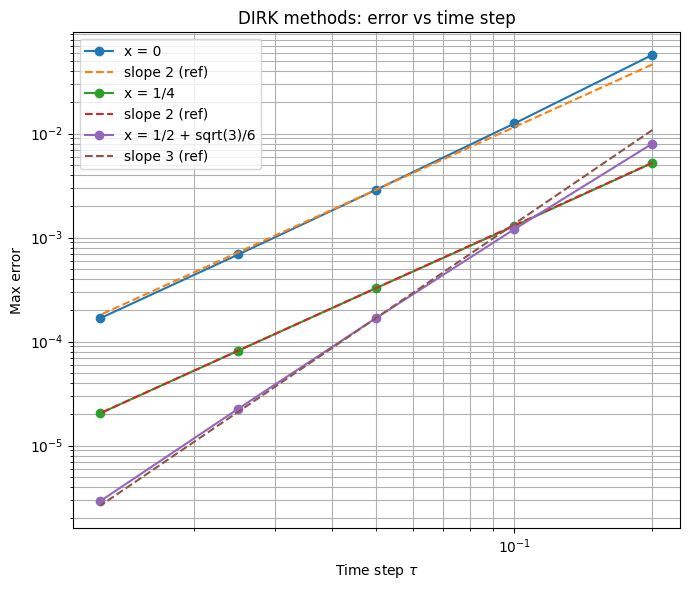

In [16]:
plt.figure(figsize=(7,6))

# Plot only DIRK methods
dirk_methods = [
    (DIRK_steppers[0], "x = 0", 2),
    (DIRK_steppers[1], "x = 1/4", 2),
    (DIRK_steppers[2], "x = 1/2 + sqrt(3)/6", 3),
]

for stepper, name, order in dirk_methods:
    errs = maxErrs[name]
    errs_f = np.array([float(e) for e in errs])
    taus = np.array(get_taus_for_method(stepper, len(errs)))

    plt.loglog(taus, errs_f, "o-", label=name)

    # Reference slope anchored at the middle data point
    k = len(taus) // 2
    C = errs_f[k] / (taus[k]**order)
    tau_ref = np.array([taus[0], taus[-1]])
    err_ref = C * tau_ref**order

    plt.loglog(
        tau_ref, err_ref, "--",
        label=f"slope {order} (ref)"
    )

plt.xlabel(r"Time step $\tau$")
plt.ylabel("Max error")
plt.title("DIRK methods: error vs time step")
plt.legend()
plt.grid(True, which="both")
plt.tight_layout()
plt.show()

## Results

The Figure above shows the maximum error as a function of the time step $\tau$ for the three DIRK methods tested. Reference lines with slopes corresponding to the expected theoretical orders are included for comparison.

For the method with $x=0$, the error decreases proportionally to $\tau^2$, closely following the slope 2 reference line across all tested step sizes. This confirms the scheme is **second order accurate in time**, as predicted by the order conditions.

The DIRK method with $x=\frac{1}{4}$ shows the same behaviour demonstrating **second order convergence**. Although its absolute error is smaller than the $x=0$ method, the asymptotic rate is unchanged.

In contrast, the DIRK method with $x=\frac{1}{2} + \frac{\sqrt{3}}{6}$ shows a significantly steeper decay of the error. The numerical results align closely with the slope 3 reference line, indicating **third order convergence**. This higher order behaviour becomes particularly clear for smaller time steps, where temporal discretisation error dominates. 

# Task 2 - Heat equation

The class `Heat` below solves a vector valued heat equation for functions $u_k \, \,(k=1,\dots, q) \, \,$ satisfying

$$
\partial_t u_k(t,x) = \mu \partial_{xx} u_k(t,x), \qquad \text{in} \, \,(0,T) \times (0,1)
$$

where $\mu$ is a fixed constant. Use Dirichlet boundary conditions

$$
u(t,0) = u_L \in \mathbb{R}^q, \qquad u(t,1) = u_R \in \mathbb{R}^q
$$

for $t \in [0,T] $ and initial conditions

$$
u(0,x) = u_0(x) \in \mathbb{R}^q
$$

for $x \in [0,1]$

In [17]:
# vector valued heat equation
class Heat:
    def __init__(self,q,points):
        self.points = points-2 # without two end points
        self.x = np.linspace(0,1,points)[1:-1]
        # parameters
        self.mu = 1/50
        self.h = 1/(points-1)
        self.q = q              # system of q uncoupled heat equations
        self.T = 1              # final time
        self.uL = np.array(q*[1.]) # left side boundary conditions
        self.uR = np.array(q*[1.]) # right side boundary conditions
        h = 1/points            # step size for space
        self.fcount = 0
        self.A = self.diffusion()

    def N0(self,explicit=True):
        # this is the expected limit for stability of the FE method
        return ( 2 * int(self.T * self.mu / self.h**2 ) if explicit else 5 )

    def exact(self,t):
        mode = lambda v: np.exp(-(v*np.pi)**2*self.mu*t)*\
                         np.sin(v*np.pi*self.x)
        ret = np.array(self.q*self.points*[1.])
        # add something to the first component
        ret[::self.q] += mode(2)
        # also add something to the second component (if it exists)
        if self.q > 1:
            ret[1::self.q] += mode(3) + mode(4)
        return ret
    # initial conditions
    def u0(self):
        return self.exact(0)

    # matrix for diffusion operator (d_xx)
    def diffusion(self):
        N = self.q * self.points
        ret = np.zeros((N,N))
        for i in range(self.points):
            for j in range(self.q):
                if i>0:
                    ret[self.q*i+j][self.q*(i-1)+j] = self.mu/self.h**2
                ret[self.q*i+j][self.q*i+j] = -2*self.mu/self.h**2
                if i<self.points-1:
                    ret[self.q*i+j][self.q*(i+1)+j] = self.mu/self.h**2
        return ret

    # right hand side for ODE
    def f(self,t,u):
        self.fcount += 1
        ret = self.A@u
        # boundary conditions
        for j in range(self.q):
            ret[j]  += self.mu/self.h**2*self.uL[j]
            ret[-self.q+j] += self.mu/self.h**2*self.uR[j]
        return ret
    # and its Jacobian
    def Df(self,t,u):
        return self.A

## Problem Setup

### Spatial discretisation

A uniform grid spacing is used with:

$$
h = \frac{1}{\text{points}-1}.
$$

The second order spatial derivative is approximated using a second order central finite difference approximation:

$$
\partial_{xx}u(x_i) \approx \frac{u_{i-1} -2u_i + u_{i+1}}{h^2},
$$

where due to Dirichlet boundary conditions, only interior points are unknown.

### Method of Lines

Spatial discretisation gives an ODE system:

$$
\dot{u}(t) = A u(t) + \text{boundary terms}.
$$

The system size is $q \times P$, where $P$ is the number of interior points. The BCs are added explicitly into the RHS.

### Exact solution

The exact solution is built from sine modes:

$$
u(x,t) = e^{-(k\pi)^2\mu t}\sin{(k\pi x)}.
$$

This allows for direct error measurements.

Choose a large value of `points` so the spatial error is small and rebuild steppers for task 2

In [18]:
points=600
prob = Heat(q=2, points=points)

fe = lambda tau, t0, y0: forwardEuler(prob.f, tau, t0, y0)
be = lambda tau, t0, y0: backwardEuler(prob.f, prob.Df, tau, t0, y0)
tr = lambda tau, t0, y0: trapezoidal(prob.f, prob.Df, tau, t0, y0)

DIRK_steppers = []
for x in x_values:
    A, b, c = pareschi_russo_DIRK_tableau(x)
    step = DIRK_stepper(A, b, c, prob.f, prob.Df)
    DIRK_steppers.append(step)

## Run Convergence Study

In [19]:
maxErrs = {}

for stepper, name in [
    (fe, "FE"),
    (be, "BE"),
    (tr, "TR"),
    (DIRK_steppers[1], "x = 1/4"),
    (DIRK_steppers[2], "x = 1/2 + sqrt(3)/6"),
]:
    print("Running:", name)
    maxErrs[name] = compute(stepper, name, verbose=True)

Running: FE


/var/folders/yc/gby2l16j0ms9dcd14yfkdt2c0000gp/T/ipykernel_22121/1848488086.py:51: RuntimeWarning: divide by zero encountered in matmul
  ret = self.A@u
/var/folders/yc/gby2l16j0ms9dcd14yfkdt2c0000gp/T/ipykernel_22121/1848488086.py:51: RuntimeWarning: overflow encountered in matmul
  ret = self.A@u
/var/folders/yc/gby2l16j0ms9dcd14yfkdt2c0000gp/T/ipykernel_22121/1848488086.py:51: RuntimeWarning: invalid value encountered in matmul
  ret = self.A@u


FE 14352 14352 0.0005264630792961004
Running: BE
BE 5 10 1.8740374564741615
BE 10 20 1.0210219809638037
BE 20 40 0.5363233500877088
BE 40 80 0.27567322531180843
BE 80 160 0.1399133299887174
Running: TR
TR 5 15 0.22335637176178297
TR 10 30 0.0550811600556972
TR 20 60 0.013482926971599649
TR 40 120 0.003179946425365102
TR 80 240 0.0006042664422050057
Running: x = 1/4
x = 1/4 5 30 0.05406248124143556
x = 1/4 10 60 0.01346896161780806
x = 1/4 20 120 0.0031719051711360017
x = 1/4 40 240 0.0006042664423747643
x = 1/4 80 480 7.802975703420204e-05
Running: x = 1/2 + sqrt(3)/6
x = 1/2 + sqrt(3)/6 5 30 0.08666248783292085
x = 1/2 + sqrt(3)/6 10 60 0.013398082905847573
x = 1/2 + sqrt(3)/6 20 120 0.00169797640070263
x = 1/2 + sqrt(3)/6 40 240 9.608132470276434e-05
x = 1/2 + sqrt(3)/6 80 480 0.00023142307549860205



FE
--
Errors: [0.0005264630792961004]
EOCs:   []

BE
--
Errors: [1.8740374564741615, 1.0210219809638037, 0.5363233500877088, 0.27567322531180843, 0.1399133299887174]
EOCs:   [0.8761358630406757, 0.9288389545233932, 0.9601439130389682, 0.9784257335789837]

TR
--
Errors: [0.22335637176178297, 0.0550811600556972, 0.013482926971599649, 0.003179946425365102, 0.0006042664422050057]
EOCs:   [2.0197165621911854, 2.0304252229423234, 2.084059356423992, 2.3957457300440224]

x = 1/4
-------
Errors: [0.05406248124143556, 0.01346896161780806, 0.0031719051711360017, 0.0006042664423747643, 7.802975703420204e-05]
EOCs:   [2.004989095745182, 2.0862170860397566, 2.3920929101040667, 2.9530885120190096]

x = 1/2 + sqrt(3)/6
-------------------
Errors: [0.08666248783292085, 0.013398082905847573, 0.00169797640070263, 9.608132470276434e-05, 0.00023142307549860205]
EOCs:   [2.6933810686069246, 2.9801382713889475, 4.14341655547071, -1.2682047774604395]


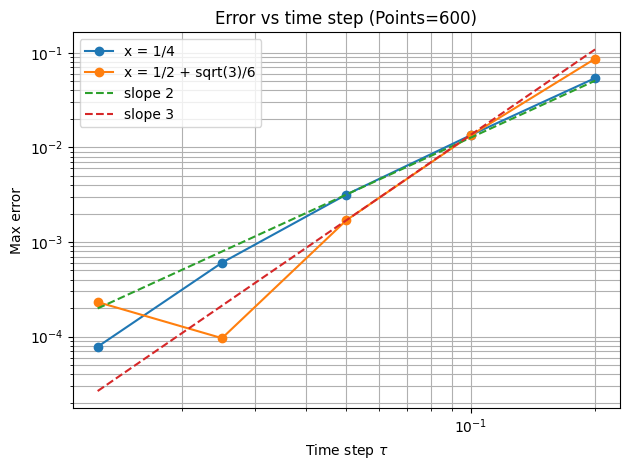

In [20]:
for name, errs in maxErrs.items():
    eocs = eoc_from_errors(errs)
    
    print(f"\n{name}")
    print("-" * len(name))

    errs_clean = [float(e) if e is not None else None for e in errs]
    eocs_clean = [float(e) if e is not None else None for e in eocs]

    print("Errors:", errs_clean)
    print("EOCs:  ", eocs_clean)

plt.figure()

# --- plot the numerical results ---
for stepper, name in [
    (DIRK_steppers[1], "x = 1/4"),
    (DIRK_steppers[2], "x = 1/2 + sqrt(3)/6"),
]:
    errs = maxErrs[name]
    errs_f = [float(e) for e in errs]
    taus = get_taus_for_method(stepper, len(errs))

    plt.loglog(taus, errs_f, "o-", label=name)

ax = plt.gca()

# ---------- helper to add a slope line ----------
def add_slope(ax, tau0, err0, p, tau_range, label):
    tau_ref = np.array(tau_range)
    err_ref = err0 * (tau_ref / tau0) ** p
    ax.loglog(tau_ref, err_ref, "--", linewidth=1.5, label=label)

# ---------- slope 2 centred on x = 1/4 ----------
name_1 = "x = 1/4"
taus_1 = get_taus_for_method(DIRK_steppers[1], len(maxErrs[name_1]))
errs_1 = np.array([float(e) for e in maxErrs[name_1]])

k1 = len(taus_1) // 2   # middle point
add_slope(
    ax,
    tau0=taus_1[k1],
    err0=errs_1[k1],
    p=2,
    tau_range=(min(taus_1), max(taus_1)),
    label="slope 2"
)

# ---------- slope 3 centred on x = 1/2 + sqrt(3)/6 ----------
name_2 = "x = 1/2 + sqrt(3)/6"
taus_2 = get_taus_for_method(DIRK_steppers[2], len(maxErrs[name_2]))
errs_2 = np.array([float(e) for e in maxErrs[name_2]])

k2 = len(taus_2) // 2
add_slope(
    ax,
    tau0=taus_2[k2],
    err0=errs_2[k2],
    p=3,
    tau_range=(min(taus_2), max(taus_2)),
    label="slope 3"
)

# ---------- labels ----------
plt.xlabel(r"Time step $\tau$")
plt.ylabel("Max error")
plt.title(f"Error vs time step (Points={points})")
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

## Results

The figure above shows the maximum error as a function of the timestep $\tau$ for the two implicit DIRK methods with paramters $x=\frac{1}{4}$ and $x=\frac{1}{2} + \frac{\sqrt{3}}{6}$, using spatial grids with $1200$ points.

**Note** Change `points` in the problem setup to 600 to visualise spatial disretisation error.

The total numerical error for the method of lines discretisation can be decomposed as 

$$
\text{error}(P,\tau) = O(\frac{1}{P^2}) + O(\tau^r),
$$

where $O(\frac{1}{P^2})$ is the spatial disretisation error from the second order finite difference approximation of the Laplacian, and $O(\tau^r)$ is the temporal error of the RK method with convergence order $r$.

**Behaviour for** $P=600$

For $P=400$, the DIRK method with $x=\frac{1}{4}$ exhibits a clear slope close to $2$ over the range of timesteps considered, consistent with its second order convergence in time. The DIRK method with $x=\frac{1}{2} + \frac{\sqrt{3}}{6}$ initially shows faster error decay, approaching a slope close to $3$, but this behaviour is limited to an intermediate range of $\tau$. At smaller timesteps, the error curve begins to flatten, indicating the spatial error term $O(\frac{1}{P^2})$ is becoming comparable to or larger than the temporal error.

**Behaviour for** $P=1200$

When the spatial resolution is increased to $P=1200$, the spatial error is reduced by approximately a factor of four, shifting the spatial error floor downward. As a result, the temporal convergence becomes clearer. The method with $x=\frac{1}{4}$ continues to follow a slope close to 2, while the method with $x=\frac{1}{2} + \frac{\sqrt{3}}{6}$ now exhibits a more extended region with slope close to 3, in agreement with its higher temporal convergence rate.

This confirms the statement from the brief that the higher the temporal order $r$ of the ODE solver, the larger the spatial resolution $P$ must be in order for the temporal error to dominate. For the third order DIRK method, a finer spatial grid is required to prevent the $O(\frac{1}{P^2})$ term from masking the $O(\tau^3)$ behaviour for small timesteps.


# Task 3 - The Brusselator Reaction-Diffusion System

Consider the 1D Brusselator reaction diffusion system with two coupled fields $u(x,t)$ and $v(x,t)$, corresponding to the first test problem studied in the cited paper. The model modifies the heat equation system with nonlinear reaction terms and is given by

$$
\begin{align}
\frac{\partial u}{\partial t} &= \mu \frac{\partial^2u}{\partial x^2} + u^2v - (b+1)u +a \\
\frac{\partial v}{\partial t} &= \mu \frac{\partial^2v}{\partial x^2} - u^2v + bu
\end{align}
$$

on $\Omega = \{0 < x < 1, t > 0\}$, with parameters $ a=1, b=3$, and $\mu = \frac{1}{50}$.

Dirichlet boundary conditions

$$
u(0,t) = u(1,t) = 1, \qquad v(0,t) = v(1,t) = 3
$$

are imposed for all $t>0$, and the initial conditions are

$$
u(x,0) = 1 + \sin{(2\pi x)}, \qquad v(x,0) = 3.
$$

## Numerical setup

The system was realised by deriving a new `Brusselator` class from the existing `Heat` class with $q=2$, reusing the same spatial discretisation and finite-difference Laplacian. The nonlinear reaction terms were added explicitly to the right hand side, and the Jacobian was implemented analytically for use with implicit RK methods. All simulations shown were run up to final time $T=10$, in order to compare with the snapshot time used in the reference paper.

Two DIRK methods were used for time integration:

- the second order method with parameter $x=\frac{1}{4},
- the third order method with $x= \frac{1}{2} + \frac{\sqrt{3}}{6}$.

In [21]:
import numpy as np

class Brusselator(Heat):
    def __init__(self, points, A=1.0, B=3.0, mu=1/50):
        super().__init__(q=2, points=points)

        self.A = A
        self.B = B
        self.mu = mu
        self.T = 1.0

        # Dirichlet boundary values
        self.uL = np.array([1.0, 3.0], dtype=float)  # [u(0,t), v(0,t)]
        self.uR = np.array([1.0, 3.0], dtype=float)  # [u(1,t), v(1,t)]

        # Build diffusion matrix once
        self.L = self.diffusion_matrix()

    def diffusion_matrix(self):
        """Second order FD Laplacian for two components (u,v) with interior unknowns only."""
        N = 2 * self.points
        L = np.zeros((N, N), dtype=float)
        alpha = self.mu / self.h**2

        for i in range(self.points):
            for comp in range(2):
                idx = 2*i + comp
                if i > 0:
                    L[idx, idx-2] = alpha
                L[idx, idx] = -2 * alpha
                if i < self.points - 1:
                    L[idx, idx+2] = alpha
        return L

    def u0(self):
        u0 = 1.0 + np.sin(2*np.pi * self.x)
        v0 = 3.0 * np.ones_like(self.x)

        y0 = np.zeros(2*self.points)
        y0[0::2] = u0
        y0[1::2] = v0
        return y0

    def f(self, t, y):
        self.fcount += 1

        u = y[0::2]
        v = y[1::2]

        # reaction
        fu = self.A - (self.B + 1.0) * u + (u**2) * v
        fv = self.B * u - (u**2) * v

        f_react = np.zeros_like(y)
        f_react[0::2] = fu
        f_react[1::2] = fv

        # diffusion on interior
        diff = self.L @ y

        # --- Dirichlet boundary forcing 
        alpha = self.mu / self.h**2

        # left boundary contributes to first interior point (i=0 in interior indexing)
        diff[0] += alpha * self.uL[0]   # u at x=0
        diff[1] += alpha * self.uL[1]   # v at x=0

        # right boundary contributes to last interior point
        diff[-2] += alpha * self.uR[0]  # u at x=1
        diff[-1] += alpha * self.uR[1]  # v at x=1
        # ------------------------------------------------------------

        return diff + f_react

    def Df(self, t, y):
        u = y[0::2]
        v = y[1::2]

        J = self.L.copy()

        for i in range(self.points):
            iu = 2*i
            iv = 2*i + 1

            J[iu, iu] += -(self.B + 1.0) + 2.0*u[i]*v[i]
            J[iu, iv] += u[i]**2
            J[iv, iu] += self.B - 2.0*u[i]*v[i]
            J[iv, iv] += -(u[i]**2)

        return J

In [22]:
prob = Brusselator(points=200)

be = lambda tau, t0, y0: backwardEuler(prob.f, prob.Df, tau, t0, y0)
tr = lambda tau, t0, y0: trapezoidal(prob.f, prob.Df, tau, t0, y0)

DIRK_steppers = []
for x in x_values:  
    A, b, c = pareschi_russo_DIRK_tableau(x)
    DIRK_steppers.append(DIRK_stepper(A, b, c, prob.f, prob.Df))

## Helper functions

The cell below defines a small set of helper functions used to extract the solution components and produce the qualatitive plots to validate the model.




In [23]:
import numpy as np
import matplotlib.pyplot as plt

def split_uv(y):
    """y is shape (2*points, Nt). Return u,v arrays of shape (points, Nt)."""
    u = y[0::2, :]
    v = y[1::2, :]
    return u, v


def plot_snapshots_side_by_side(prob, run_left, run_right, times, field="u", title=""):
    """
    Plot snapshots (multiple times on same axes) for two methods side by side.

    run_left  = (name, t, u, v)
    run_right = (name, t, u, v)
    field: "u" or "v"
    """
    x = prob.x

    def get_field(run):
        name, t, u, v = run
        return name, t, (u if field == "u" else v)

    nameL, tL, yL = get_field(run_left)
    nameR, tR, yR = get_field(run_right)

    idxsL = [int(np.argmin(np.abs(tL - tt))) for tt in times]
    idxsR = [int(np.argmin(np.abs(tR - tt))) for tt in times]

    fig, axes = plt.subplots(1, 2, figsize=(12, 8), sharex=True, sharey=True)

    # Left panel
    for tt, k in zip(times, idxsL):
        axes[0].plot(x, yL[:, k], label=f"t={tL[k]:.2f}")
    axes[0].set_title(nameL)
    axes[0].set_xlabel("x")
    axes[0].set_ylabel(f"{field}(x,t)")
    axes[0].grid(True)
    axes[0].legend()

    # Right panel
    for tt, k in zip(times, idxsR):
        axes[1].plot(x, yR[:, k], label=f"t={tR[k]:.2f}")
    axes[1].set_title(nameR)
    axes[1].set_xlabel("x")
    axes[1].grid(True)
    axes[1].legend()

    fig.suptitle(title or f"{field}(x,t) snapshots (multiple times)")
    plt.tight_layout()
    plt.show()

def run_brusselator(prob, stepper, name, tau):
    N = int(np.ceil(prob.T / tau))
    tau = prob.T / N

    y0 = prob.u0()
    prob.fcount = 0

    t, y = evolve(stepper=stepper, tau=tau, N=N, y0=y0)
    u, v = split_uv(y)

    print(f"{name}: tau={tau:.3e}, N={N}, fcount={prob.fcount}")
    return t, u, v

/var/folders/yc/gby2l16j0ms9dcd14yfkdt2c0000gp/T/ipykernel_22121/641918506.py:59: RuntimeWarning: divide by zero encountered in matmul
  diff = self.L @ y
/var/folders/yc/gby2l16j0ms9dcd14yfkdt2c0000gp/T/ipykernel_22121/641918506.py:59: RuntimeWarning: overflow encountered in matmul
  diff = self.L @ y
/var/folders/yc/gby2l16j0ms9dcd14yfkdt2c0000gp/T/ipykernel_22121/641918506.py:59: RuntimeWarning: invalid value encountered in matmul
  diff = self.L @ y


DIRK x=1/4: tau=2.000e-02, N=500, fcount=4000
DIRK x=1/2 + sqrt(3)/6: tau=2.000e-02, N=500, fcount=4105


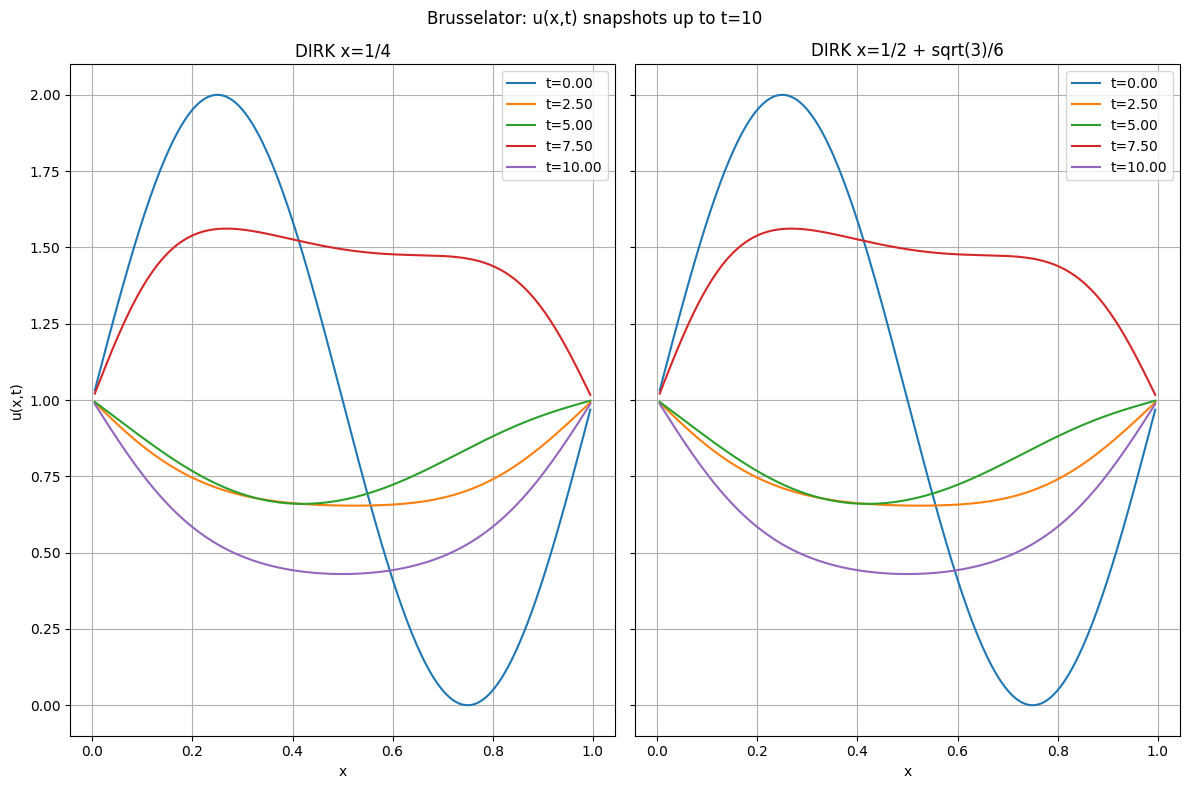

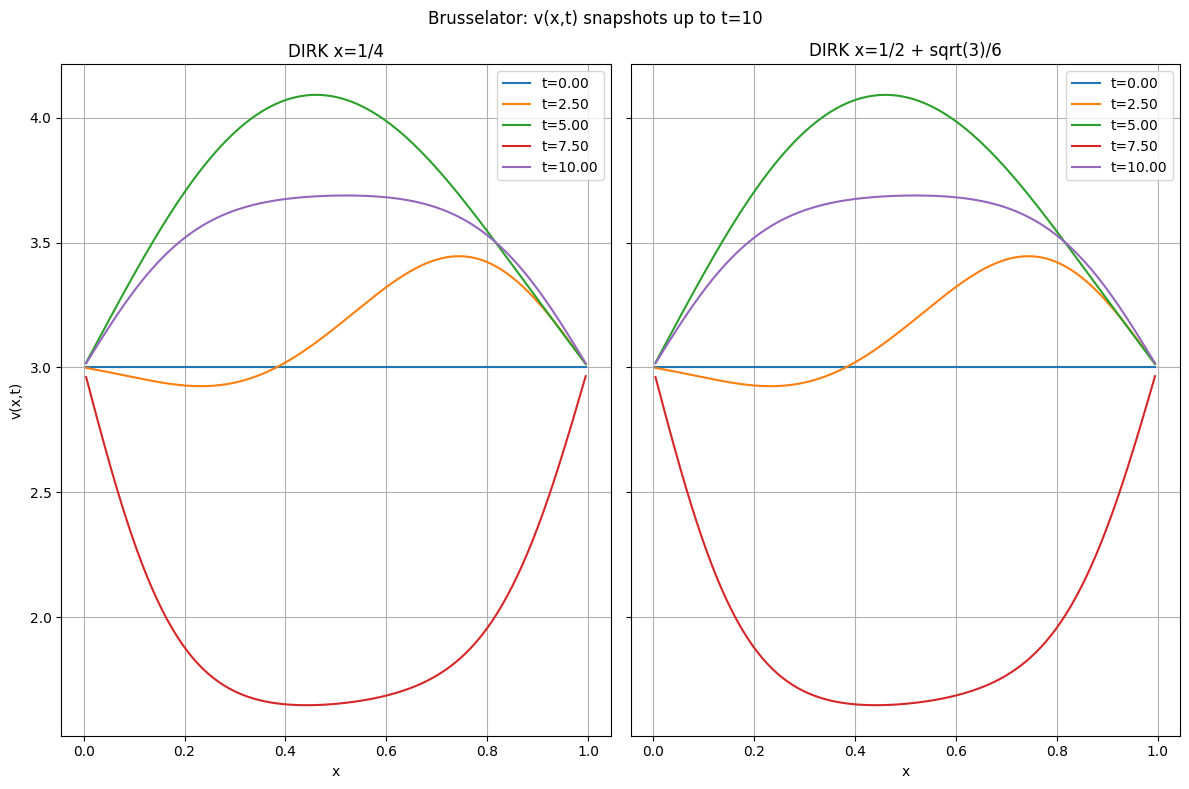

In [24]:
# Run to the same final time as the paper
prob.T = 10.0
prob.mu = 1/50

snapshot_times = (0, 2.5, 5.0, 7.5, 10.0)

t1, u1, v1 = run_brusselator(prob, DIRK_steppers[1],
                            "DIRK x=1/4", tau=0.02)
t2, u2, v2 = run_brusselator(prob, DIRK_steppers[2],
                            "DIRK x=1/2 + sqrt(3)/6", tau=0.02)

run1 = ("DIRK x=1/4", t1, u1, v1)
run2 = ("DIRK x=1/2 + sqrt(3)/6", t2, u2, v2)

plot_snapshots_side_by_side(
    prob, run1, run2,
    snapshot_times,
    field="u",
    title="Brusselator: u(x,t) snapshots up to t=10"
)

plot_snapshots_side_by_side(
    prob, run1, run2,
    snapshot_times,
    field="v",
    title="Brusselator: v(x,t) snapshots up to t=10"
)

## Qualitative comparison with the literature

Since there is no closed form solution availible for the Brusselator, validation is performed by qualitative comparisons with Figure 2 in the cited paper. In particular, spatial snapshots of $u(x,t)$ and $v(x,t)$ at $t=10$ are compared.

For both DIRK methods, the numerical solution reproduces the key qualitative features reported in the paper:

- **Correct boundary behaviour**:
At all times, $u(x,t)$ returns to 1 and $v(x,t)$ returns to 3 at the domain boundaries $x=0$ and $x=1$, consistent with the imposed Dirichlet conditions.

- **Correct steady state shapes at** $t=10$:
The field $u(x,10)$ exhibits a pronounced U-shaped profile with a minimum near the centre of the domain, while $v(x,t)$ shows an inverted U profile with a central maximum.

- **Transient evolution**:
Intermediate snapshots illustrate the expected redistrubution of mass driven by the nonlinear coupling. The initial sinusoidal perturbation in $u$ relaxes towards a symmetric profile, while $v$, initially spatially uniform, develops a central peak induced by the reaction terms.

- **Method independence**:
Both DIRK schemes produce visually indistinguishable solutions at the final time. This indicates the observed behaviour is governed by the model dynamics rather than numerical artefacts.

## Discussion 

The close qualitative agreement between the computed solutions and the published figures provides strong evidence that the Brusselator system has been implemented correctly. The correct handling of boundary conditions, initial profiles, diffusion, and nonlinear reaction terms is essential to reproduce the characteristic final $u$ and $v$ profiles. 

Small differences in amplitude and smoothness are expected due to different choices of spatial resolution, timestep size, and numerical scheme. The overall agreement confirms that the code captures the essential physics of the Brusselator model.